# Lesson 3. Tuning until the bicycle stays up

Tuning means changing one gain at a time, plotting the result, and keeping
only a combination that holds the bicycle upright. The bicycle, the motors,
and the controller code stay the same. Only the outer PID numbers change.

## Learning objectives

By the end of this lesson you will be able to:

1. State the difference between a fallen trace and a holding trace.
2. Show that proportional action alone does not balance this bicycle.
3. Find the derivative gain at which the bicycle starts to hold.
4. Save a working set of outer gains in `configs/tutorial.yaml`.

## Glossary

| Term | Meaning |
| --- | --- |
| Tuning | Changing controller numbers and checking the result, one change at a time. |
| Holding | |roll| stays well under 20° after the first second and settles near 0°. |
| Fallen | |roll| passes about 45°. |
| Proportional (P) | Command grows with the current lean. |
| Integral (I) | Command grows if a lean lasts. |
| Derivative (D) | Command grows with how fast the lean is changing. |
| Outer gains | `pid_kp_roll`, `pid_ki_roll`, `pid_kd_roll`, `pid_kp_steer`. These are the knobs in this lesson. |
| Inner gains | `steer_kp` and `steer_ki`. Leave these unchanged. |


## Step 1. Start the lesson

Run the next cell. Continue when you see `project_root:`.


In [1]:
import os
import sys

def choose_mujoco_gl(platform, display, existing):
    if existing:
        return existing
    if str(platform).startswith("linux") and not display:
        return "egl"
    return None

chosen = choose_mujoco_gl(sys.platform, os.environ.get("DISPLAY"), os.environ.get("MUJOCO_GL"))
if chosen and "MUJOCO_GL" not in os.environ:
    os.environ["MUJOCO_GL"] = chosen

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

from sim.config import load_config
from sim.loop import make_sim, run_headless, summarize
from sim.pid_controller import RollSteerPID, apply_speed_refs

np.set_printoptions(precision=4, suppress=True)
print("project_root:", project_root)
print("platform:", sys.platform, "MUJOCO_GL:", os.environ.get("MUJOCO_GL", "(unset)"))


project_root: /home/lmbike2/bike-workshop/bike_mujoco_sim
platform: linux MUJOCO_GL: egl


## Step 2. Define two helpers

The next cell defines `ride` and `plot_roll`. `ride` runs a few seconds and
prints whether the bicycle fell. `plot_roll` draws roll versus time. Run the
cell once. Later steps call those names. You do not need to edit the cell.


In [2]:
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")

def ride(cfg, seconds, label):
    cfg = replace(cfg, duration=float(seconds))
    sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
    history = run_headless(sim, duration=seconds)
    rolls = np.degrees(np.abs(np.asarray(history["roll"], dtype=float)))
    tip = np.where(rolls > 45.0)[0]
    tip_t = float(history["time"][tip[0]]) if len(tip) else None
    print(
        f"{label}: max |roll|={float(rolls.max()):.1f} deg"
        + (f", tip at {tip_t:.2f}s" if tip_t is not None else ", stayed under 45 deg")
    )
    return history, tip_t

def plot_roll(history, title, ax=None):
    time_s = np.asarray(history["time"], dtype=float)
    roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
    ax.plot(time_s, roll_deg)
    ax.axhline(0.0, color="0.7", linewidth=0.8)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("roll (deg)")
    ax.set_title(title)
    if own:
        plt.show()
    return roll_deg


## Step 3. Try proportional action alone

Set the integral and derivative gains to 0, then raise the proportional gain
from 2 to 9.

The window cell uses the last of those values: proportional gain 9, integral
0, derivative 0. Close the window, then run the graph cell. That cell prints
every proportional gain and draws only the last one.

Compare the printed lines with the graph. The title is the gain, not a conclusion.

If the window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, then run the window cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, pid_kp_roll=9.0, pid_ki_roll=0.0, pid_kd_roll=0.0, pid_kp_steer=1.116, duration=3.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("P only, kp = 9, ki = 0, kd = 0")
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


P-only kp=2.0: max |roll|=97.2 deg, tip at 0.54s


P-only kp=4.0: max |roll|=97.7 deg, tip at 0.54s


P-only kp=6.0: max |roll|=100.6 deg, tip at 0.56s


P-only kp=7.5: max |roll|=106.5 deg, tip at 0.56s


P-only kp=9.0: max |roll|=112.4 deg, tip at 0.56s


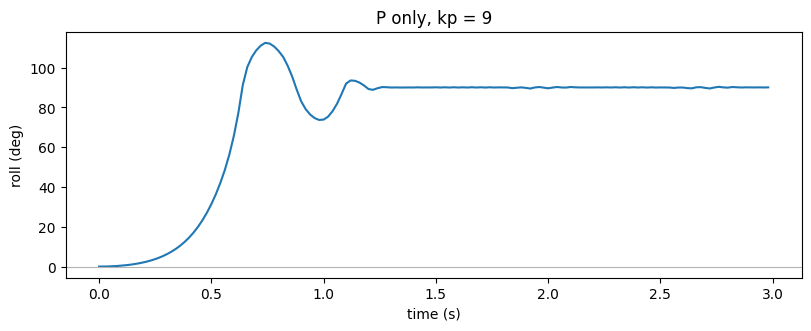

array([  0.    ,   0.0001,   0.0419,   0.1461,   0.2738,   0.4447,
         0.6709,   0.9469,   1.2795,   1.6788,   2.1529,   2.7133,
         3.3726,   4.1451,   5.0476,   6.0991,   7.3215,   8.7397,
        10.3818,  12.28  ,  14.4701,  16.9928,  19.8933,  23.2222,
        27.0356,  31.396 ,  36.3737,  42.0506,  48.5699,  56.2845,
        65.6143,  77.117 ,  91.274 , 100.2578, 105.2667, 108.6708,
       111.0624, 112.4299, 112.0457, 110.5613, 108.2387, 105.3128,
       100.8845,  95.4537,  88.9516,  83.0242,  79.1017,  76.3882,
        74.6048,  73.675 ,  73.8615,  75.3454,  78.1327,  81.8912,
        86.7567,  91.9586,  93.5239,  93.3552,  92.4378,  90.9763,
        89.2074,  88.8317,  89.6153,  90.1877,  90.1454,  89.9723,
        90.0258,  89.9746,  90.0179,  90.0085,  89.9897,  90.0748,
        89.9912,  90.0273,  90.0057,  90.0923,  89.9798,  90.0934,
        89.9716,  90.1104,  89.9732,  90.0894,  89.9687,  90.1281,
        89.9764,  90.1048,  89.9635,  90.1003,  89.9842,  90.0

In [4]:
base = load_config(tutorial_yaml)
for kp in (2.0, 4.0, 6.0, 7.5, 9.0):
    cfg = replace(base, pid_kp_roll=kp, pid_ki_roll=0.0, pid_kd_roll=0.0, pid_kp_steer=1.116)
    history, tip_t = ride(cfg, 3.0, f"P-only kp={kp}")
plot_roll(history, "P only, kp = 9")


## Step 4. Raise the derivative gain

Freeze `pid_kp_roll` near 7.5 and `pid_ki_roll` at 0. Raise `pid_kd_roll`.

The derivative term commands more steering when the lean is changing faster.

Two window cells follow, then one graph cell. The windows are `pid_kd_roll = 5`
and `pid_kd_roll = 8`, with the proportional gain at 7.5. Close each window
before you open the next. The graph cell prints the full list and draws those
two values. Decide from the traces and the printed lines what changed.

If a window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, then run that window cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, pid_kp_roll=7.5, pid_ki_roll=0.0, pid_kd_roll=5.0, pid_kp_steer=1.116, duration=5.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("kp = 7.5, ki = 0, kd = 5")
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(cfg, pid_kp_roll=7.5, pid_ki_roll=0.0, pid_kd_roll=8.0, pid_kp_steer=1.116, duration=5.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("kp = 7.5, ki = 0, kd = 8")
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


kp=7.5 ki=0 kd=3.0: max |roll|=93.5 deg, tip at 0.64s


kp=7.5 ki=0 kd=5.0: max |roll|=96.3 deg, tip at 0.72s


kp=7.5 ki=0 kd=6.0: max |roll|=14.8 deg, stayed under 45 deg


kp=7.5 ki=0 kd=8.0: max |roll|=10.2 deg, stayed under 45 deg


kp=7.5 ki=0 kd=11.0: max |roll|=6.8 deg, stayed under 45 deg


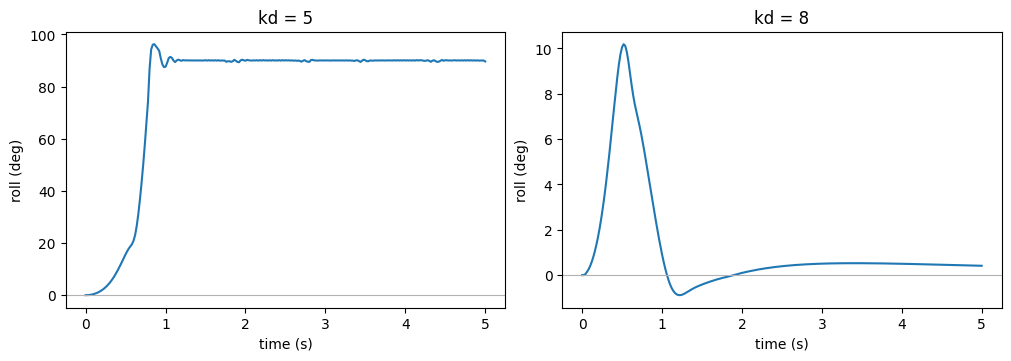

In [7]:
base = load_config(tutorial_yaml)
histories = {}
for kd in (3.0, 5.0, 6.0, 8.0, 11.0):
    cfg = replace(base, pid_kp_roll=7.5, pid_ki_roll=0.0, pid_kd_roll=kd, pid_kp_steer=1.116)
    history, tip_t = ride(cfg, 5.0, f"kp=7.5 ki=0 kd={kd}")
    histories[kd] = history

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
plot_roll(histories[5.0], "kd = 5", ax=axes[0])
plot_roll(histories[8.0], "kd = 8", ax=axes[1])
plt.show()


## Step 5. Compare two gain sets

One run uses proportional 5, integral 0, derivative 6. The other uses the
gains in the table, which are also stored in `configs/new_bike.yaml`.

| Gain | Value |
| --- | --- |
| `pid_kp_roll` | 7.54 |
| `pid_ki_roll` | 1.26 |
| `pid_kd_roll` | 11.26 |
| `pid_kp_steer` | 1.12 |

The integral term reacts to a lean that lasts. `pid_kp_steer` near 1.1 pulls the handlebars toward straight.

Run the two window cells, then the graph cell. The first window uses
proportional 5, integral 0, derivative 6. The second window loads
`configs/new_bike.yaml`. The graph draws those two runs side by side.
Decide from the traces which lean stays smaller.

If a window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, then run that window cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(
    cfg,
    pid_kp_roll=5.0,
    pid_ki_roll=0.0,
    pid_kd_roll=6.0,
    pid_kp_steer=1.1164231977942145,
    duration=6.0,
)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("kp = 5, ki = 0, kd = 6")
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(new_bike_yaml)
cfg = replace(cfg, duration=6.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("gains from", os.path.relpath(new_bike_yaml, project_root))
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


weak (struggle): max |roll|=97.8 deg, tip at 0.82s


tuned: max |roll|=6.6 deg, stayed under 45 deg


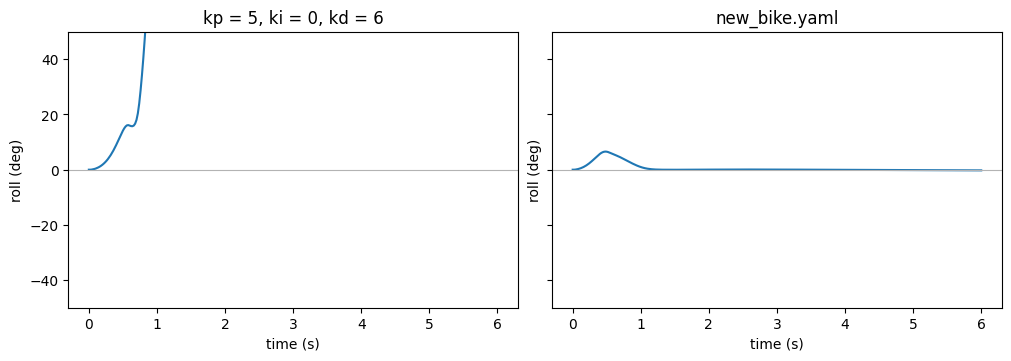

tuned max |roll| = 6.56 deg (want well under 20)


In [10]:
# In-memory tuned gains (same numbers you should save into tutorial.yaml).
tuned = replace(
    load_config(new_bike_yaml),
    duration=6.0,
)
# Keep a copy of the weak starting gains for the side-by-side plot.
weak = replace(
    load_config(tutorial_yaml),
    pid_kp_roll=5.0,
    pid_ki_roll=0.0,
    pid_kd_roll=6.0,
    pid_kp_steer=1.1164231977942145,
    duration=6.0,
)
weak_hist, _ = ride(weak, 6.0, "weak (struggle)")
tuned_hist, tip = ride(tuned, 6.0, "tuned")
if tip is not None:
    raise RuntimeError("tuned gains should stay upright")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True, constrained_layout=True)
plot_roll(weak_hist, "kp = 5, ki = 0, kd = 6", ax=axes[0])
plot_roll(tuned_hist, "new_bike.yaml", ax=axes[1])
axes[0].set_ylim(-50, 50)
axes[1].set_ylim(-50, 50)
plt.show()

rolls = np.degrees(np.abs(np.asarray(tuned_hist["roll"], dtype=float)))
print(f"tuned max |roll| = {float(rolls.max()):.2f} deg (want well under 20)")
if float(rolls.max()) >= 20.0:
    raise RuntimeError("tuned ride leaned too far")


## Step 6. Save the tuned gains

The comparison above used numbers in memory. To keep them, open
`configs/tutorial.yaml` and set the four `pid_*` lines to the table in
Step 5. Save the file. Leave `configs/new_bike.yaml` unchanged. That file
is the known-good copy. Your working copy is `tutorial.yaml`.

Then run the next cell.

Expected result after a correct save: numbers near 7.54, 1.26, 11.26, and
1.12. If the print still shows 5, 0, and 6, the file was not saved with the
new values. Edit it and run the cell again.


In [11]:
# After you save tutorial.yaml, this cell should print the tuned numbers.
cfg_disk = load_config(tutorial_yaml)
print(
    "tutorial.yaml on disk: kp={:.4f} ki={:.4f} kd={:.4f} kp_steer={:.4f}".format(
        cfg_disk.pid_kp_roll, cfg_disk.pid_ki_roll, cfg_disk.pid_kd_roll, cfg_disk.pid_kp_steer
    )
)
print(
    "If those still look like 5 / 0 / 6, open the YAML, paste the tuned gains, save, and re-run."
)


tutorial.yaml on disk: kp=5.0000 ki=0.0000 kd=6.0000 kp_steer=1.1164
If those still look like 5 / 0 / 6, open the YAML, paste the tuned gains, save, and re-run.


## Discussion

### Why did every proportional-only trial fall?

Proportional action only sees how far the bicycle has already leaned. At the start of a fall, the lean rate matters more, and that rate is what the derivative term sees. With the derivative gain at 0, raising the proportional gain from 2 to 9 still tipped at about 0.5 s.

### What changed once the derivative gain passed about 6?

With the proportional gain near 7.5, a derivative gain of 5 still fell, a little later than with no derivative term. A derivative gain of 6 and above held, because the controller steers harder when the lean is changing faster.

### If it already holds, what are the integral and steer terms for?

They refine a hold you already have. The integral term slowly removes a small lean that sits there. The steer term brings the handlebars back toward straight.


## Questions

Answer these before you run the next cells.

1. In Step 3, did raising the proportional gain from 2 to 9 stop the lean from crossing 45°?
2. From the Step 4 graphs, predict `pid_kd_roll = 7`: does |roll| cross 45°, or stay under it? Then predict `pid_kd_roll = 0`.

The window cell and the graph cell must use the same `kd_try`. Start with `7.0` in both. Close the window, then run the graph. Run both again with `4.0`, then with `0.0`. The proportional gain stays at 7.5 and the integral gain stays at 0.

If the window cell reports that MuJoCo was already imported, choose
**Kernel → Restart Kernel**, set `kd_try` again, and run the window cell.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


# Keep this equal to kd_try in the graph cell.
kd_try = 7.0
tutorial_yaml = os.path.join(project_root, "configs", "tutorial.yaml")
cfg = load_config(tutorial_yaml)
cfg = replace(
    cfg,
    pid_kp_roll=7.5,
    pid_ki_roll=0.0,
    pid_kd_roll=float(kd_try),
    pid_kp_steer=1.116,
    duration=4.0,
)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("kp = 7.5, ki = 0, kd =", cfg.pid_kd_roll)
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


kp=7.5 ki=0 kd=7.0: max |roll|=12.1 deg, stayed under 45 deg


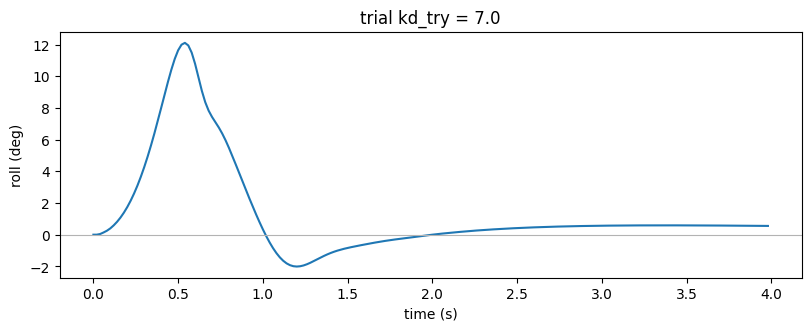

Result: held. Roll stayed under 45 deg.


In [13]:
# Edit kd_try and run again. Use the same value in the window cell.
# Trials: 7.0, then 4.0, then 0.0
kp_try = 7.5
kd_try = 7.0
cfg = replace(
    load_config(tutorial_yaml),
    pid_kp_roll=kp_try,
    pid_ki_roll=0.0,
    pid_kd_roll=float(kd_try),
    pid_kp_steer=1.116,
)
history, tip_t = ride(cfg, 4.0, f"kp={kp_try} ki=0 kd={kd_try}")
plot_roll(history, f"trial kd_try = {kd_try}")
if tip_t is None:
    print("Result: held. Roll stayed under 45 deg.")
else:
    print(f"Result: fell at {tip_t:.2f} s.")
